In [30]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- LOAD DATA ---
df = pd.read_csv("cleaned_patient_with_hospital.csv")

# --- FILTER DISEASE ---
df = df[df["disease_type"].str.lower().str.contains("diarrhea")].copy()

In [31]:
# --- PARSE DATE ---
df["date_disease_start"] = pd.to_datetime(
    df["date_disease_start"],
    dayfirst=True,
    errors="coerce"
)
df = df.dropna(subset=["date_disease_start"])

# df["year"] = df["date_disease_start"].dt.year
# df["month"] = df["date_disease_start"].dt.month
df["year"] = df["date_disease_start"].dt.year
df["week"] = df["date_disease_start"].dt.isocalendar().week
# --- AGGREGATE ---
# monthly_cases = (
#     df.groupby(["district", "year", "month"])
#     .size()
#     .reset_index(name="case_count")
# )
weekly_cases = (
    df.groupby(["district", "year", "week"])
    .size()
    .reset_index(name="case_count")
)

# Sort properly for lag features
weekly_cases["date"] = pd.to_datetime(
    weekly_cases["year"].astype(str) + "-W" + weekly_cases["week"].astype(str) + "-1",
    format="%G-W%V-%u"   # ISO week format
)
# monthly_cases = monthly_cases.sort_values(by=["district", "year", "month"])
# monthly_cases.head()
weekly_cases = weekly_cases.sort_values(["district", "date"])
weekly_cases.head()

,district,year,week,case_count,date
0,bang_bon,2026,1,38,2025-12-29
1,bang_bon,2026,2,67,2026-01-05
2,bang_bon,2026,3,99,2026-01-12
3,bang_bon,2026,4,81,2026-01-19
4,bang_bon,2026,5,77,2026-01-26


In [32]:
# --- FEATURE ENGINEERING ---
# monthly_cases["lag_1"] = monthly_cases.groupby("district")["case_count"].shift(1)
# monthly_cases["lag_2"] = monthly_cases.groupby("district")["case_count"].shift(2)

# monthly_cases["rolling_avg_2"] = monthly_cases[["lag_1", "lag_2"]].mean(axis=1)
# monthly_cases["rolling_max_2"] = monthly_cases[["lag_1", "lag_2"]].max(axis=1)

# monthly_cases["month_of_year"] = monthly_cases["month"]
weekly_cases["lag_1"] = weekly_cases.groupby("district")["case_count"].shift(1)
weekly_cases["lag_2"] = weekly_cases.groupby("district")["case_count"].shift(2)

weekly_cases["rolling_avg_2"] = weekly_cases[["lag_1", "lag_2"]].mean(axis=1)
weekly_cases["rolling_max_2"] = weekly_cases[["lag_1", "lag_2"]].max(axis=1)

weekly_cases["week_of_year"] = weekly_cases["week"]

# Drop rows with NaN (from lag)
# monthly_cases = monthly_cases.dropna()
# weekly_cases = weekly_cases.dropna()
weekly_cases[["lag_1", "lag_2"]] = weekly_cases[["lag_1", "lag_2"]].fillna(0)

# --- LABEL CREATION ---
# threshold = np.percentile(monthly_cases["case_count"], 75)
# monthly_cases["label"] = (monthly_cases["case_count"] > threshold).astype(int)
# monthly_cases.head()
threshold = np.percentile(weekly_cases["case_count"], 75)
weekly_cases["label"] = (weekly_cases["case_count"] > threshold).astype(int)
weekly_cases.head()

,district,year,week,case_count,date,lag_1,lag_2,rolling_avg_2,rolling_max_2,week_of_year,label
0,bang_bon,2026,1,38,2025-12-29,0.0,0.0,NaN,NaN,1,0
1,bang_bon,2026,2,67,2026-01-05,38.0,0.0,38.0,38.0,2,0
2,bang_bon,2026,3,99,2026-01-12,67.0,38.0,52.5,67.0,3,1
3,bang_bon,2026,4,81,2026-01-19,99.0,67.0,83.0,99.0,4,1
4,bang_bon,2026,5,77,2026-01-26,81.0,99.0,90.0,99.0,5,1


In [33]:
# --- CREATE DATE FOR SPLIT ---
# monthly_cases["date"] = pd.to_datetime(
#     monthly_cases["year"].astype(str) + "-" + monthly_cases["month"].astype(str) + "-01"
# )

# split_index = int(len(monthly_cases) * 0.8)

# train_set = monthly_cases.iloc[:split_index]
# test_set  = monthly_cases.iloc[split_index:]
weekly_cases = weekly_cases.sort_values(['district','date']).reset_index(drop=True)

split_index = int(len(weekly_cases) * 0.8)

train_set = weekly_cases.iloc[:split_index]
test_set  = weekly_cases.iloc[split_index:]
train_set.head()

,district,year,week,case_count,date,lag_1,lag_2,rolling_avg_2,rolling_max_2,week_of_year,label
0,bang_bon,2026,1,38,2025-12-29,0.0,0.0,NaN,NaN,1,0
1,bang_bon,2026,2,67,2026-01-05,38.0,0.0,38.0,38.0,2,0
2,bang_bon,2026,3,99,2026-01-12,67.0,38.0,52.5,67.0,3,1
3,bang_bon,2026,4,81,2026-01-19,99.0,67.0,83.0,99.0,4,1
4,bang_bon,2026,5,77,2026-01-26,81.0,99.0,90.0,99.0,5,1


In [34]:
# --- FEATURES / TARGET ---
features = ["lag_1", "lag_2", "rolling_avg_2", "rolling_max_2", "week_of_year"]
target = "case_count"

X_train = train_set[features]
y_train = train_set[target]

X_test = test_set[features]
y_test = test_set[target]
X_train.head()

,lag_1,lag_2,rolling_avg_2,rolling_max_2,week_of_year
0,0.0,0.0,NaN,NaN,1
1,38.0,0.0,38.0,38.0,2
2,67.0,38.0,52.5,67.0,3
3,99.0,67.0,83.0,99.0,4
4,81.0,99.0,90.0,99.0,5


In [35]:
# --- MODEL ---
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- EVALUATION ---
y_pred = model.predict(X_test)

# print("Precision:", precision_score(y_test, y_pred))
# print("Recall:", recall_score(y_test, y_pred))
# print("F1 Score:", f1_score(y_test, y_pred))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("MSE: ", mse)
print("R2: ", r2)
X_test['predicted'] = y_pred
# --- PREDICTION (LATEST PER DISTRICT) ---
# latest_rows = monthly_cases.sort_values("date").groupby("district").tail(1)
# latest_rows = weekly_cases.sort_values("date").groupby("district").tail(1)

# latest_rows["prediction"] = model.predict(latest_rows[features])

# Flag districts
# flagged = latest_rows[latest_rows["prediction"] == 1]

# print("\nDistricts needing diarrhea medicine:")
# print(flagged[["district", "prediction"]])

MAE: 8.976311471929995
MSE:  190.19156733969237
R2:  0.8406791765443308


C:\Users\thanyathorn\AppData\Local\Temp\ipykernel_18280\1070432670.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['predicted'] = y_pred


In [36]:
X_test.head()

,lag_1,lag_2,rolling_avg_2,rolling_max_2,week_of_year,predicted
540,5.0,1.0,3.0,5.0,12,4.690000
541,6.0,5.0,5.5,6.0,13,4.470000
542,0.0,0.0,NaN,NaN,1,34.084261
543,50.0,0.0,50.0,50.0,2,77.606371
544,76.0,50.0,63.0,76.0,3,69.130000


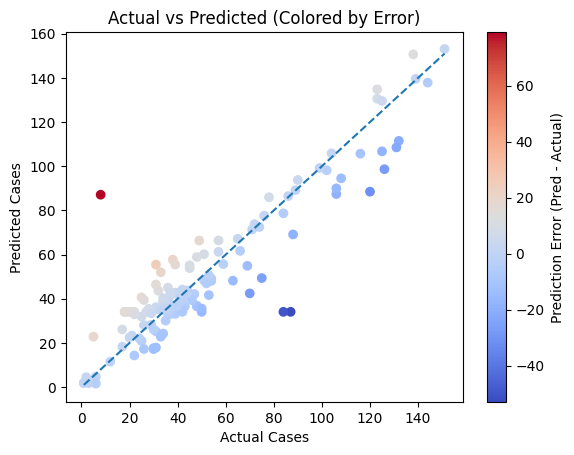

In [37]:
import matplotlib.pyplot as plt
import numpy as np

error = y_pred - y_test

plt.scatter(y_test, y_pred, c=error, cmap="coolwarm")
plt.colorbar(label="Prediction Error (Pred - Actual)")

plt.xlabel("Actual Cases")
plt.ylabel("Predicted Cases")
plt.title("Actual vs Predicted (Colored by Error)")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.show()

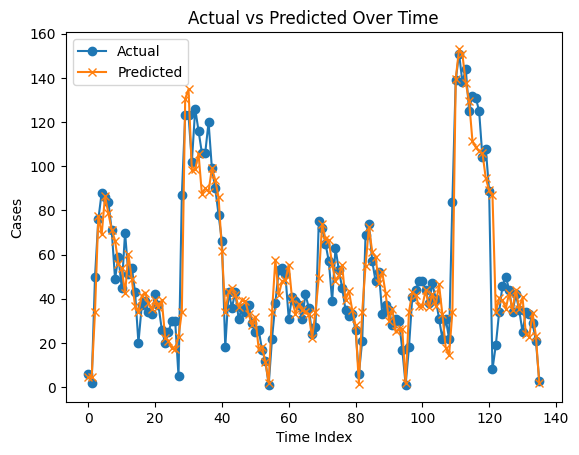

In [38]:
plt.plot(y_test.values, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')

plt.xlabel("Time Index")
plt.ylabel("Cases")
plt.title("Actual vs Predicted Over Time")

plt.legend()
plt.show()

In [39]:
# print(monthly_cases["month"].unique())      # what months exist
# print(monthly_cases["year"].unique())       # what years exist
# print(monthly_cases["date"].min(), monthly_cases["date"].max())  # full date range

In [40]:
X_test['district'] = test_set['district']
X_test.head()

C:\Users\thanyathorn\AppData\Local\Temp\ipykernel_18280\3557274300.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['district'] = test_set['district']


,lag_1,lag_2,rolling_avg_2,rolling_max_2,week_of_year,predicted,district
540,5.0,1.0,3.0,5.0,12,4.690000,samphanthawong
541,6.0,5.0,5.5,6.0,13,4.470000,samphanthawong
542,0.0,0.0,NaN,NaN,1,34.084261,saphan_sung
543,50.0,0.0,50.0,50.0,2,77.606371,saphan_sung
544,76.0,50.0,63.0,76.0,3,69.130000,saphan_sung
